In [31]:
from sklearn.datasets import load_diabetes

In [32]:
dataset=load_diabetes()

In [33]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [34]:
dataset.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [35]:
import pandas as pd

In [36]:

df_diabetes = pd.DataFrame(dataset.data , columns=['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'])

In [37]:
x=df_diabetes
y=dataset['target']

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train , X_test , y_train , y_test = train_test_split(x,y , test_size=.30 , random_state=5)

In [40]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
402,0.110727,0.050680,-0.033151,-0.022885,-0.004321,0.020293,-0.061809,0.071210,0.015568,0.044485
259,0.012648,-0.044642,-0.036385,0.042529,-0.013953,0.012934,-0.026833,0.005157,-0.043984,0.007207
24,-0.063635,-0.044642,0.035829,-0.022885,-0.030464,-0.018850,-0.006584,-0.002592,-0.025953,-0.054925
247,-0.081798,-0.044642,-0.081653,-0.040099,0.002559,-0.018537,0.070730,-0.039493,-0.010903,-0.092204
275,-0.005515,0.050680,-0.011595,0.011544,-0.022208,-0.015406,-0.021311,-0.002592,0.011011,0.069338


In [41]:
X_train.corr() ##pearson corelation

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.247628,0.197611,0.304493,0.327211,0.271531,-0.115000,0.278050,0.345341,0.346429
sex,0.247628,1.000000,0.083243,0.237126,0.038213,0.150908,-0.392645,0.364827,0.161626,0.246433
bmi,0.197611,0.083243,1.000000,0.416620,0.246483,0.241725,-0.321641,0.373134,0.427016,0.385183
bp,0.304493,0.237126,0.416620,1.000000,0.272282,0.198306,-0.167187,0.256194,0.411595,0.414290
s1,0.327211,0.038213,0.246483,0.272282,1.000000,0.882899,0.050567,0.523908,0.508642,0.271951
s2,0.271531,0.150908,0.241725,0.198306,0.882899,1.000000,-0.219512,0.660823,0.286352,0.240711
s3,-0.115000,-0.392645,-0.321641,-0.167187,0.050567,-0.219512,1.000000,-0.753942,-0.368948,-0.319056
s4,0.278050,0.364827,0.373134,0.256194,0.523908,0.660823,-0.753942,1.000000,0.582947,0.398578
s5,0.345341,0.161626,0.427016,0.411595,0.508642,0.286352,-0.368948,0.582947,1.000000,0.482511
s6,0.346429,0.246433,0.385183,0.414290,0.271951,0.240711,-0.319056,0.398578,0.482511,1.000000


In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: >

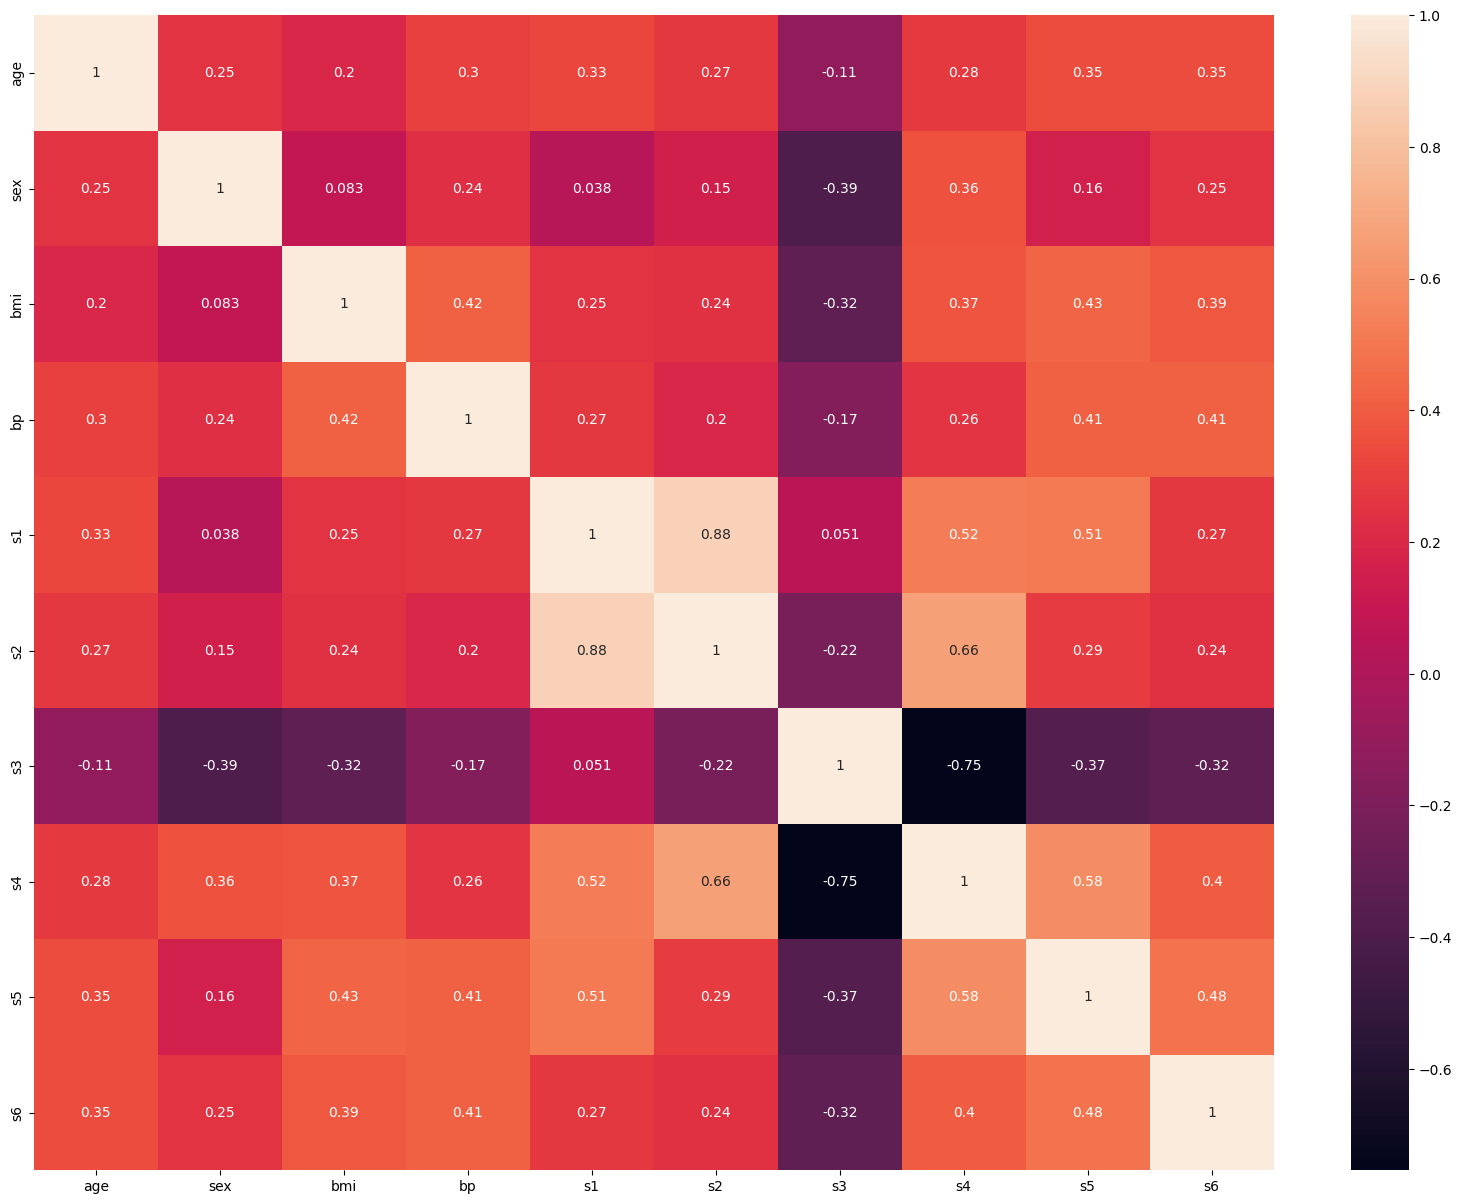

In [43]:
import seaborn as sns
plt.figure(figsize=(20,15))
sns.heatmap(X_train.corr() , annot= True)

In [44]:

from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [45]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}
param

{'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
 'max_features': ['auto', 'sqrt', 'log2']}

In [46]:
from sklearn.model_selection import GridSearchCV
regressor=DecisionTreeRegressor()
grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [47]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 2,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [48]:
## predictions
y_pred=grid.predict(X_test)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.36507037012521715
53.51362633845932
4137.439086792537


In [49]:
selectedmodel=DecisionTreeRegressor(criterion='friedman_mse',max_depth=4,max_features='log2',splitter='random')
selectedmodel.fit(X_train,y_train)

,criterion,'friedman_mse'
,splitter,'random'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5089285714285714, 0.9, 'x[7] <= -0.024\nfriedman_mse = 5674.455\nsamples = 309\nvalue = 151.184'),
 Text(0.2857142857142857, 0.7, 'x[8] <= 0.011\nfriedman_mse = 3934.562\nsamples = 121\nvalue = 114.273'),
 Text(0.39732142857142855, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'x[8] <= -0.014\nfriedman_mse = 3265.488\nsamples = 110\nvalue = 107.145'),
 Text(0.07142857142857142, 0.3, 'x[2] <= 0.008\nfriedman_mse = 2756.275\nsamples = 93\nvalue = 100.935'),
 Text(0.03571428571428571, 0.1, 'friedman_mse = 1931.556\nsamples = 75\nvalue = 90.667'),
 Text(0.10714285714285714, 0.1, 'friedman_mse = 3922.534\nsamples = 18\nvalue = 143.722'),
 Text(0.21428571428571427, 0.3, 'x[4] <= -0.052\nfriedman_mse = 4686.104\nsamples = 17\nvalue = 141.118'),
 Text(0.17857142857142858, 0.1, 'friedman_mse = 1122.25\nsamples = 2\nvalue = 218.5'),
 Text(0.25, 0.1, 'friedman_mse = 4256.427\nsamples = 15\nvalue = 130.8'),
 Text(0.42857142857142855, 0.5, 'x[4] <= 0.034\nfriedman_mse = 5037.521\nsamples 

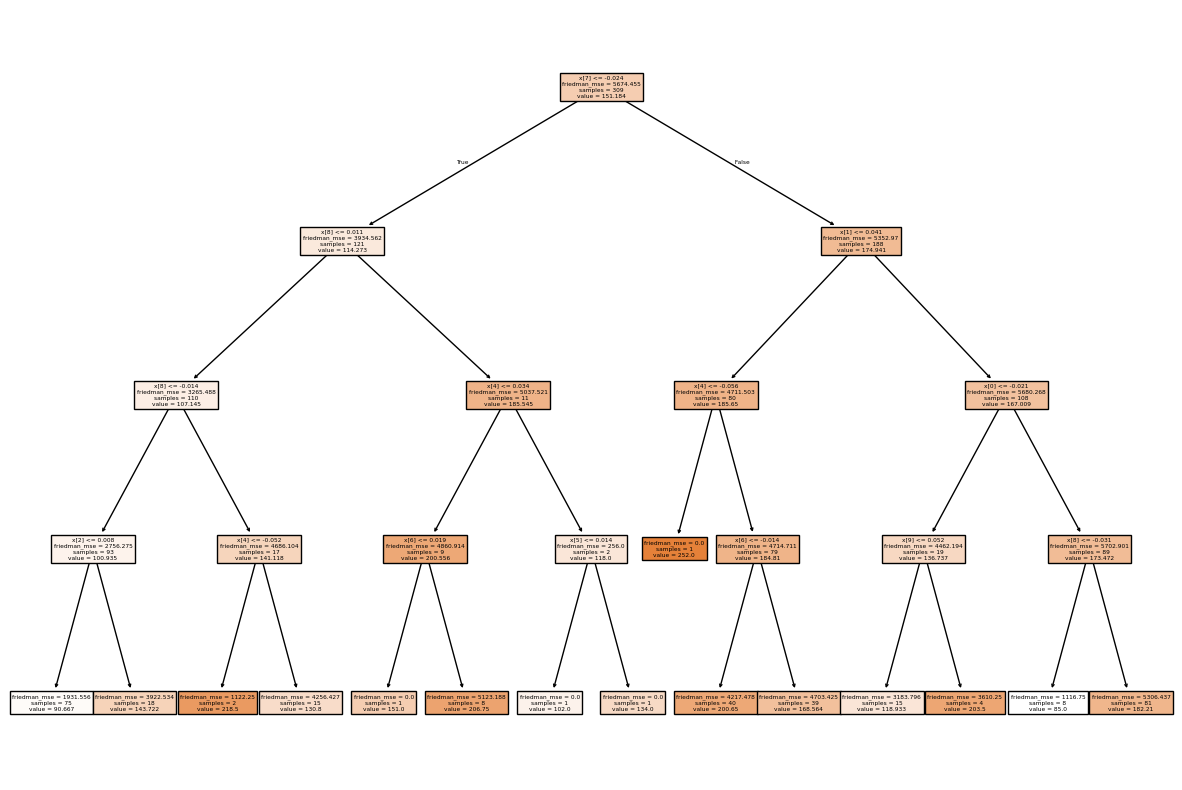

In [50]:
##Visualize the Decision Tree
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectedmodel,filled=True)